# Feature Weight Analysis

Fitted parameters from the myopic model for each LLM:

| Parameter | Meaning |
|---|---|
| `w_centre` | Reward for pieces close to board center |
| `w_c2` | Reward for 2 **adjacent** pieces in a viable (unblocked) window |
| `w_uc2` | Reward for 2 **non-adjacent** pieces in a viable window |
| `w_three` | Reward for 3-in-a-row in a viable window |
| `w_four` | Reward for 4-in-a-row (win) |
| `C` | Active scaling: self-features are multiplied by C, so C>1 means the agent values its own threats more than the opponent's |

Value function: `V(s) = w_centre*(centre_self - centre_opp) + dot(w[1:], C*phi_self[1:] - phi_opp[1:])`

We use the **myopic** variant throughout (γ=0, depth-1 only), since it consistently outperforms full tree backpropagation.

In [30]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
RESULTS_DIR = Path('./results')

name_replacement = {
    'accounts/fireworks/models/deepseek-r1-0528-medium':              'deepseek-r1',
    'accounts/fireworks/models/deepseek-v3p1-medium':                 'deepseek-v3.1-thinking',
    'accounts/fireworks/models/glm-4p5-medium':                       'glm-4.5-thinking',
    'accounts/fireworks/models/kimi-k2-instruct-0905':                'kimi-k2-instruct',
    'accounts/fireworks/models/llama-v3p3-70b-instruct':              'llama-v3.3-70b',
    'accounts/fireworks/models/qwen3-235b-a22b-thinking-2507-medium': 'qwen3-235b-a22b-thinking',
    'claude-opus-4-1-20250805':        'claude-opus-4.1',
    'claude-sonnet-4-20250514':        'claude-sonnet-4',
    'claude-sonnet-4-5@20250929':      'claude-sonnet-4.5',
    'deepseek-ai/deepseek-v3.1-maas':  'deepseek-v3.1',
    'deepseek-reasoner':               'deepseek-v3.2-thinking',
    'gemini-2.5-pro':                  'gemini-2.5-pro',
    'glm-4.6':                         'glm-4.6',
    'gpt-4o-2024-08-06':               'gpt-4o',
    'gpt-5-2025-08-07-high':           'gpt-5-high',
    'gpt-5-2025-08-07-medium':         'gpt-5-medium',
    'gpt-5-mini-2025-08-07-high':      'gpt-5-mini-high',
    'gpt-5-mini-2025-08-07-medium':    'gpt-5-mini-medium',
    'grok-4-fast-reasoning':           'grok-4-fast-reasoning',
    'kimi-k2-thinking':                'kimi-k2-thinking',
    'o3-2025-04-16-high':              'o3-high',
    'openai/gpt-oss-120b-maas-high':   'gpt-oss-120b-high',
    'openai/gpt-oss-120b-maas-medium': 'gpt-oss-120b-medium',
    'qwen/qwen3-next-80b-a3b-thinking-maas': 'qwen3-next-80b-a3b-thinking',
    'qwen3-max':                       'qwen3-max',
}

safe_to_raw = {raw.replace('/', '_').replace('@', '_'): raw for raw in name_replacement}

def is_open_source(model_name):
    keys = ['deepseek', 'glm', 'kimi', 'llama', 'qwen', 'oss']
    return any(k in model_name.lower() for k in keys)

# ── Load myopic fit results (open-source models only) ────────────────────────────────────────────────
records = []
for fpath in sorted(RESULTS_DIR.glob('fit_results_full_*_myopic.json')):
    safe_name = fpath.stem.replace('fit_results_full_', '').replace('_myopic', '')
    raw_name  = safe_to_raw.get(safe_name, safe_name.replace('_', '/'))
    display   = name_replacement.get(raw_name, safe_name)
    if not is_open_source(display):
        continue
    with open(fpath) as f:
        d = json.load(f)
    w = d['weights']
    records.append({
        'model':      display,
        'n_samples':  d['n_samples'],
        'w_centre':   w[0],
        'w_c2':       w[1],
        'w_uc2':      w[2],
        'w_three':    w[3],
        'w_four':     w[4],
        'C':          d['C'],
        'accuracy':   d['train_accuracy'],
        'nll':        d['train_nll_per_sample'],
    })

df = pd.DataFrame(records)
df = df[df['n_samples'] > 20].reset_index(drop=True)
print(f'Loaded {len(df)} open-source models')
df[['model','w_centre','w_c2','w_uc2','w_three','w_four','C','accuracy']].round(3)

Loaded 13 open-source models


,model,w_centre,w_c2,w_uc2,w_three,w_four,C,accuracy
0,deepseek-r1,0.640,0.568,0.461,3.320,10.800,1.658,0.569
1,deepseek-v3.1-thinking,0.865,0.723,0.383,3.431,14.312,2.137,0.607
2,glm-4.5-thinking,0.568,0.265,0.316,1.029,4.865,0.250,0.457
3,kimi-k2-instruct,1.068,0.262,0.289,2.188,18.196,0.250,0.588
4,qwen3-235b-a22b-thinking,1.751,0.665,0.458,3.938,30.174,1.859,0.618
5,deepseek-v3.1,0.097,0.396,0.503,1.872,20.670,0.735,0.572
6,deepseek-v3.2-thinking,1.294,0.672,0.387,3.758,12.969,2.046,0.591
7,glm-4.6,0.370,0.497,0.684,1.506,4.013,1.099,0.456
8,kimi-k2-thinking,1.277,0.579,0.189,3.248,10.350,1.635,0.558
9,gpt-oss-120b-high,0.738,0.817,0.780,3.920,31.709,2.425,0.603


In [31]:
# ── Config: filter outliers ────────────────────────────────────────────────
EXCLUDE_OUTLIERS = True

OUTLIERS = ['llama-v3.3-70b']  # no fit results available

df_plot = df[~df['model'].isin(OUTLIERS)].copy() if EXCLUDE_OUTLIERS else df.copy()
print(f'Models in analysis: {len(df_plot)}')
print(df_plot['model'].tolist())

Models in analysis: 13
['deepseek-r1', 'deepseek-v3.1-thinking', 'glm-4.5-thinking', 'kimi-k2-instruct', 'qwen3-235b-a22b-thinking', 'deepseek-v3.1', 'deepseek-v3.2-thinking', 'glm-4.6', 'kimi-k2-thinking', 'gpt-oss-120b-high', 'gpt-oss-120b-medium', 'qwen3-max', 'qwen3-next-80b-a3b-thinking']


## 1. Feature weights per model

Each bar shows a fitted weight. Positive = feature is rewarded; negative = feature is penalized.  
Models are sorted by accuracy (myopic fit).

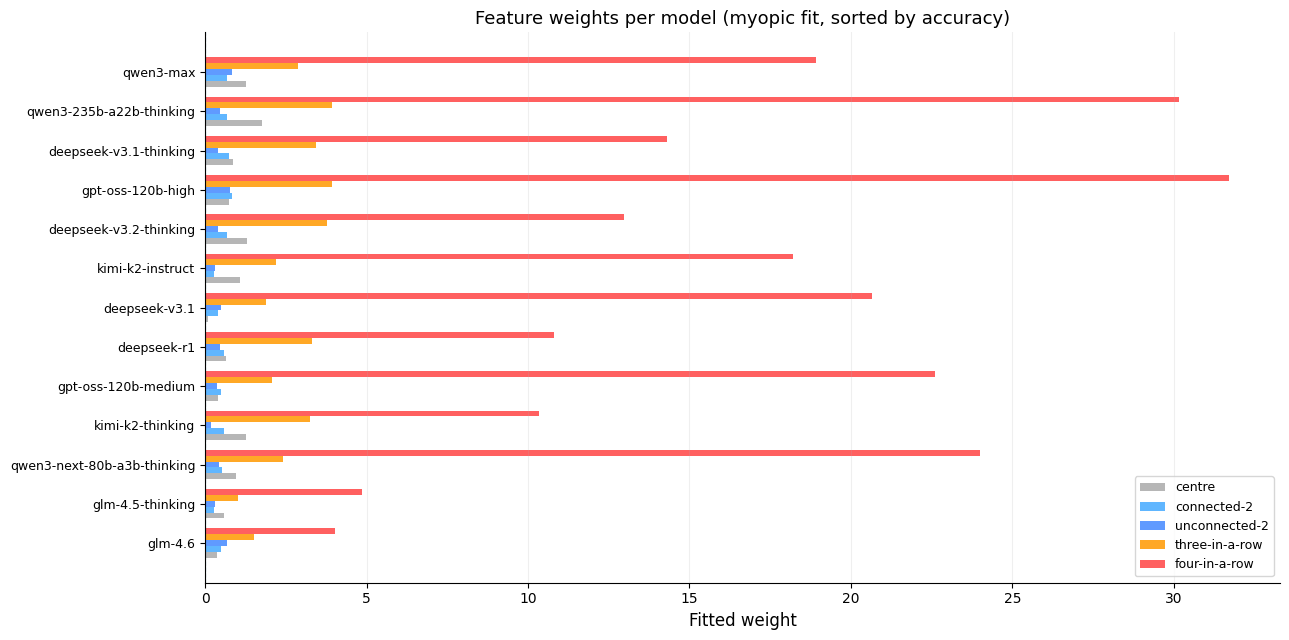

In [32]:
WEIGHT_COLS = ['w_centre', 'w_c2', 'w_uc2', 'w_three', 'w_four']
WEIGHT_LABELS = ['centre', 'connected-2', 'unconnected-2', 'three-in-a-row', 'four-in-a-row']
COLORS = ['#aaaaaa', '#44aaff', '#4488ff', '#ff9900', '#ff4444']

df_sorted = df_plot.sort_values('accuracy', ascending=True)
n = len(df_sorted)
y = np.arange(n)
BAR_H = 0.15
offsets = np.linspace(-2, 2, 5) * BAR_H

fig, ax = plt.subplots(figsize=(13, max(6, n * 0.5)))

for col, label, color, offset in zip(WEIGHT_COLS, WEIGHT_LABELS, COLORS, offsets):
    ax.barh(y + offset, df_sorted[col], BAR_H, label=label, color=color, alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(df_sorted['model'], fontsize=9)
ax.axvline(0, lw=0.8, ls='--')
ax.set_xlabel('Fitted weight', fontsize=12)
ax.set_title('Feature weights per model (myopic fit, sorted by accuracy)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
# plt.savefig('figures/feature_weights_per_model.pdf', facecolor='#444444')
plt.show()

## 2. Heatmap: weights × models

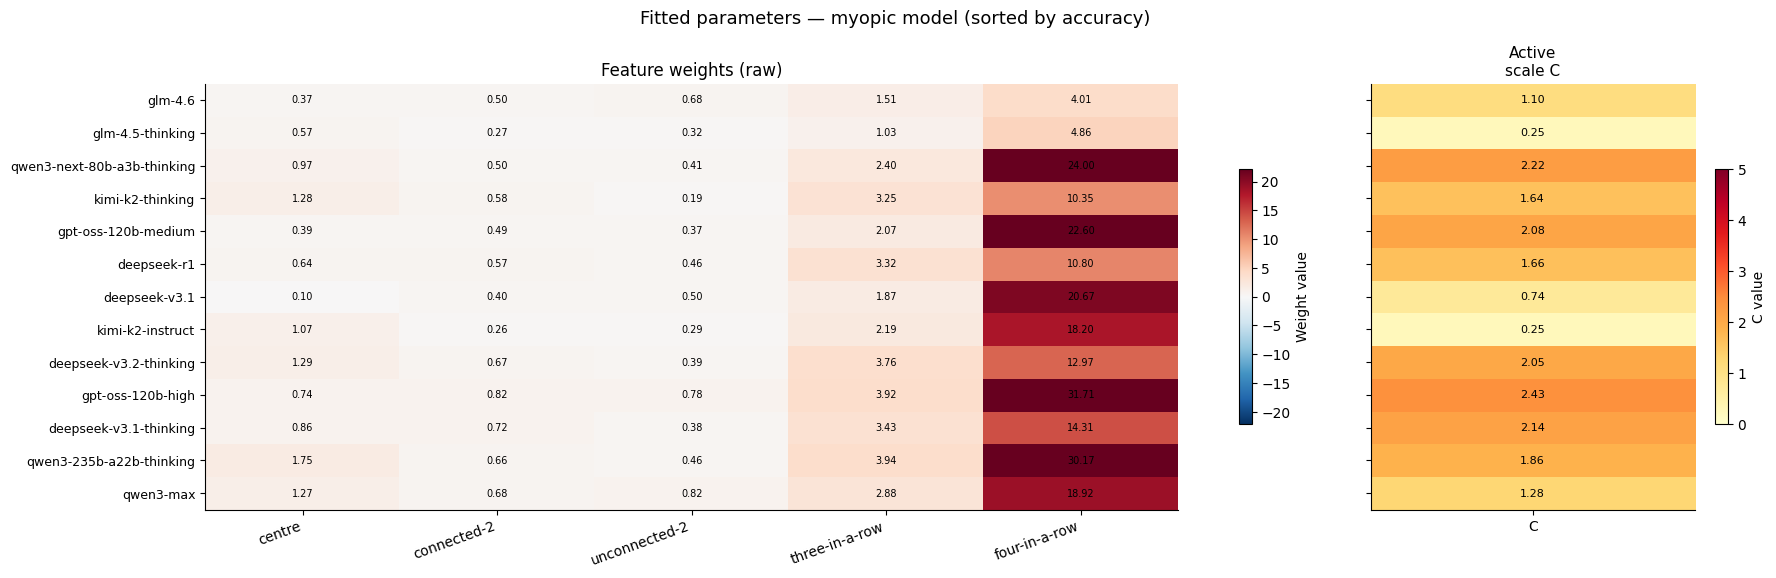

In [33]:
from matplotlib.colors import TwoSlopeNorm

df_heat = df_sorted.set_index('model')[WEIGHT_COLS + ['C']]
col_labels = WEIGHT_LABELS + ['C (active scale)']

# Normalise each column to [-1, 1] for visual comparability
mat_raw = df_heat.values.astype(float)
mat_norm = mat_raw / (np.abs(mat_raw).max(axis=0, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, n * 0.45)),
                         gridspec_kw={'width_ratios': [3, 1]})

# Left: raw weights
ax = axes[0]
vmax = np.percentile(np.abs(mat_raw[:, :5]), 95)  # exclude C for scale
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(mat_raw[:, :5], aspect='auto', cmap='RdBu_r', norm=norm)
ax.set_xticks(range(5))
ax.set_xticklabels(WEIGHT_LABELS, fontsize=10, rotation=20, ha='right')
ax.set_yticks(range(n))
ax.set_yticklabels(df_sorted['model'], fontsize=9)
for i in range(n):
    for j in range(5):
        ax.text(j, i, f'{mat_raw[i,j]:.2f}', ha='center', va='center', fontsize=7, color='black')
plt.colorbar(im, ax=ax, label='Weight value', shrink=0.6)
ax.set_title('Feature weights (raw)', fontsize=12)

# Right: C parameter
ax2 = axes[1]
c_vals = mat_raw[:, 5:6]
im2 = ax2.imshow(c_vals, aspect='auto', cmap='YlOrRd',
                 vmin=0, vmax=5)
ax2.set_xticks([0])
ax2.set_xticklabels(['C'], fontsize=10)
ax2.set_yticks(range(n))
ax2.set_yticklabels([])
for i in range(n):
    ax2.text(0, i, f'{c_vals[i,0]:.2f}', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im2, ax=ax2, label='C value', shrink=0.6)
ax2.set_title('Active\nscale C', fontsize=11)

plt.suptitle('Fitted parameters — myopic model (sorted by accuracy)', fontsize=13)
plt.tight_layout()
# plt.savefig('figures/feature_weights_heatmap.pdf', facecolor='#444444')
plt.show()

## 3. Distribution of each weight across models

Box plots showing cross-model variability in each fitted parameter.

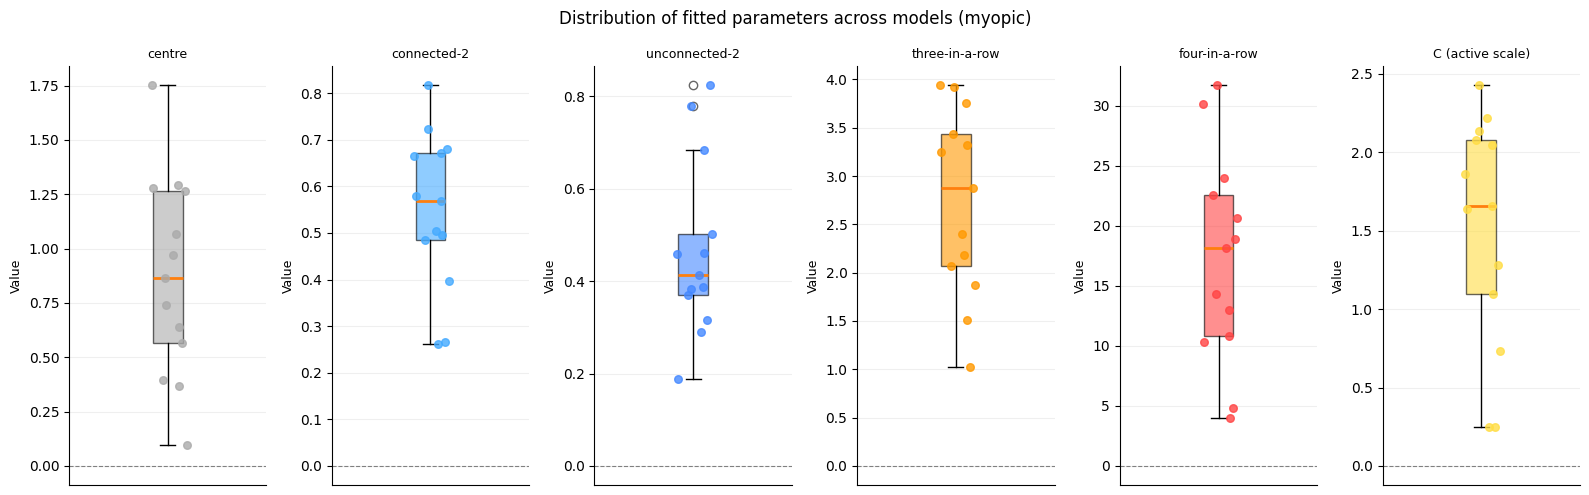

Summary statistics:
       w_centre    w_c2   w_uc2  w_three  w_four       C
count    13.000  13.000  13.000   13.000  13.000  13.000
mean      0.869   0.547   0.466    2.735  17.198   1.513
std       0.462   0.169   0.190    0.959   8.710   0.736
min       0.097   0.262   0.189    1.029   4.013   0.250
25%       0.568   0.485   0.369    2.067  10.800   1.099
50%       0.865   0.568   0.414    2.876  18.196   1.658
75%       1.267   0.672   0.503    3.431  22.600   2.077
max       1.751   0.817   0.824    3.938  31.709   2.425


In [34]:
fig, axes = plt.subplots(1, 6, figsize=(16, 5))

for ax, col, label, color in zip(axes,
    WEIGHT_COLS + ['C'],
    WEIGHT_LABELS + ['C (active scale)'],
    COLORS + ['#ffdd44']):

    vals = df_plot[col].values
    bp = ax.boxplot(vals, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(lw=2),
                    whiskerprops=dict(),
                    capprops=dict(),
                    flierprops=dict(marker='o', color=color, alpha=0.6))
    ax.axhline(0, color='gray', lw=0.8, ls='--')

    # Scatter individual points
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
    ax.scatter(1 + jitter, vals, c=color, s=30, alpha=0.8, zorder=3)

    ax.set_xticks([])
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Distribution of fitted parameters across models (myopic)', fontsize=12)
plt.tight_layout()
# plt.savefig('figures/feature_weight_distributions.pdf', facecolor='#444444')
plt.show()

print('Summary statistics:')
print(df_plot[WEIGHT_COLS + ['C']].describe().round(3))

## 4. Feature weights vs win rate

Do stronger models assign higher weight to certain features?

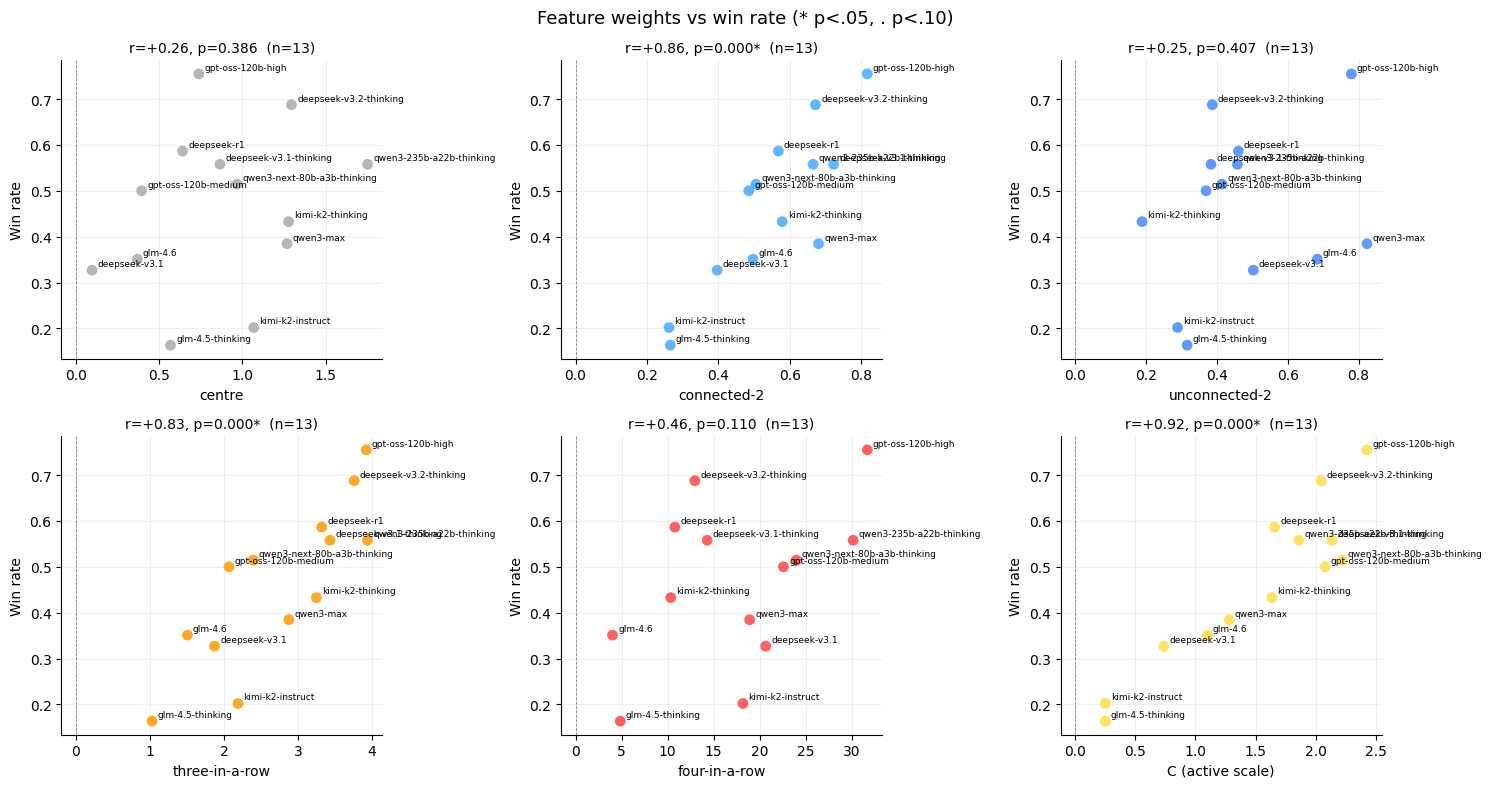

In [35]:
# Load win rates from pkl
pkl_name_map = {
    'qwen3-next-80b-a3b-thinking': 'qwen3-next-80b-a3b-thinking',
}

try:
    import pandas as pd_
    df_raw = pd_.read_pickle('game_trees_df_annotated_preprocessed.pkl')
    win_rate = (
        df_raw.groupby(['game_path', 'model_names'])['outcome_perspective']
        .mean().reset_index()
        .groupby('model_names')['outcome_perspective'].mean()
    )
    win_rate.index = win_rate.index.map(lambda x: pkl_name_map.get(x, x))
    df_plot['win_rate'] = df_plot['model'].map(win_rate)
    pkl_ok = True
    missing = df_plot[df_plot['win_rate'].isna()]['model'].tolist()
    if missing:
        print(f'Missing win rates for: {missing}')
except Exception as e:
    pkl_ok = False
    print(f'Could not load pkl: {e}')

if pkl_ok:
    sub = df_plot.dropna(subset=['win_rate'])
    n_sub = len(sub)
    n_cols = 3
    params_to_plot = WEIGHT_COLS + ['C']
    n_rows = (len(params_to_plot) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, col, label, color in zip(axes, params_to_plot,
                                      WEIGHT_LABELS + ['C (active scale)'],
                                      COLORS + ['#ffdd44']):
        x = sub[col].values
        y = sub['win_rate'].values
        ax.scatter(x, y, c=color, s=60, alpha=0.85, edgecolors='none', zorder=3)
        for xi, yi, name in zip(x, y, sub['model']):
            ax.annotate(name, (xi, yi), xytext=(4, 3),
                        textcoords='offset points', fontsize=6.5)
        ax.axvline(0, color='gray', lw=0.6, ls='--')
        r, p = pearsonr(x, y)
        sig = '*' if p < 0.05 else ('.' if p < 0.1 else '')
        ax.set_xlabel(label, fontsize=10)
        ax.set_ylabel('Win rate', fontsize=10)
        ax.set_title(f'r={r:+.2f}, p={p:.3f}{sig}  (n={n_sub})', fontsize=10)
        ax.grid(True, alpha=0.2)

    for ax in axes[len(params_to_plot):]:
        ax.set_visible(False)

    plt.suptitle('Feature weights vs win rate (* p<.05, . p<.10)', fontsize=13)
    plt.tight_layout()
    # plt.savefig('figures/feature_weights_vs_winrate.pdf', facecolor='#444444')
    plt.show()

## 5. Correlation summary table

In [36]:
if pkl_ok:
    sub = df_plot.dropna(subset=['win_rate'])
    targets = ['win_rate', 'accuracy']
    rows = []
    for col, label in zip(WEIGHT_COLS + ['C'], WEIGHT_LABELS + ['C']):
        row = {'feature': label}
        for tgt in targets:
            x = sub[col].values
            y = sub[tgt].values
            r_p, p_p = pearsonr(x, y)
            r_s, p_s = spearmanr(x, y)
            row[f'pearson_r_{tgt}']   = r_p
            row[f'pearson_p_{tgt}']   = p_p
            row[f'spearman_r_{tgt}']  = r_s
            row[f'spearman_p_{tgt}']  = p_s
        rows.append(row)

    corr_df = pd.DataFrame(rows).set_index('feature')
    print('=== Pearson r (* p<.05, . p<.10) ===')
    for tgt in targets:
        print(f'\nTarget: {tgt}')
        for feat in corr_df.index:
            r = corr_df.loc[feat, f'pearson_r_{tgt}']
            p = corr_df.loc[feat, f'pearson_p_{tgt}']
            sig = '*' if p < 0.05 else ('.' if p < 0.1 else ' ')
            print(f'  {feat:<20}: r={r:+.3f}  p={p:.3f} {sig}')

=== Pearson r (* p<.05, . p<.10) ===

Target: win_rate
  centre              : r=+0.263  p=0.386  
  connected-2         : r=+0.860  p=0.000 *
  unconnected-2       : r=+0.252  p=0.407  
  three-in-a-row      : r=+0.827  p=0.000 *
  four-in-a-row       : r=+0.464  p=0.110  
  C                   : r=+0.922  p=0.000 *

Target: accuracy
  centre              : r=+0.511  p=0.074 .
  connected-2         : r=+0.586  p=0.035 *
  unconnected-2       : r=+0.177  p=0.563  
  three-in-a-row      : r=+0.767  p=0.002 *
  four-in-a-row       : r=+0.623  p=0.023 *
  C                   : r=+0.387  p=0.191  


## 6. Relative weight analysis

Weights normalized by `w_four` (relative to the win-reward) to remove scale effects.
This isolates the model's *preference profile* independent of how consistently it plays.

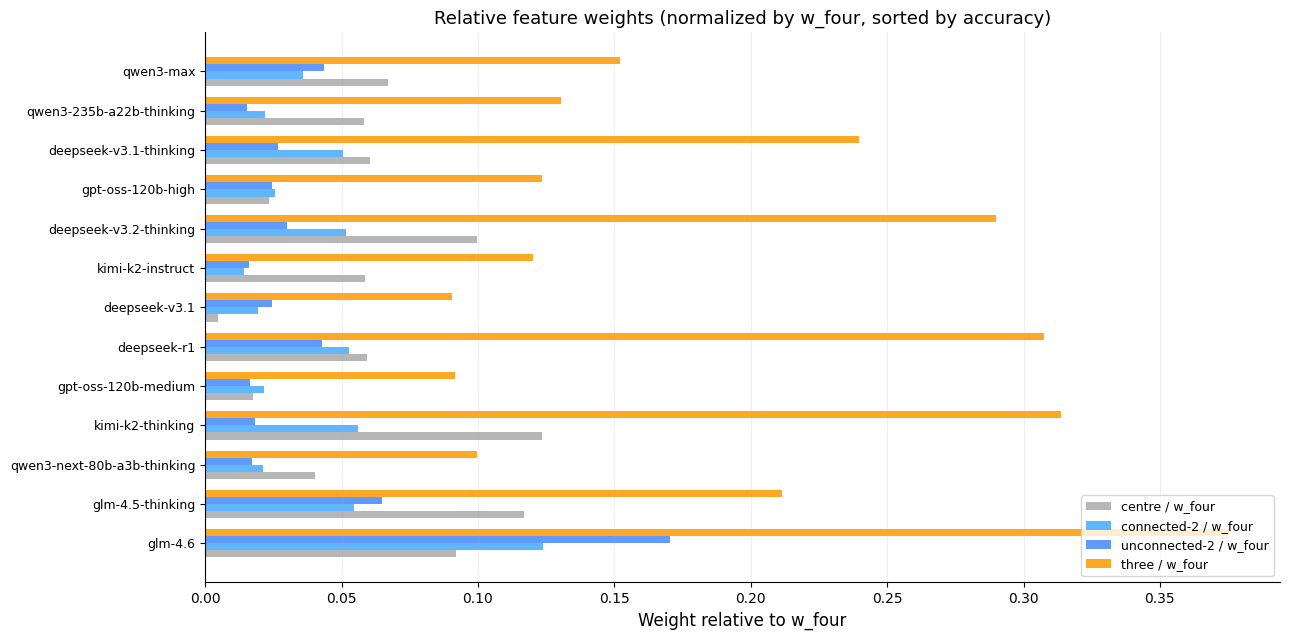

In [37]:
# Normalize weights by w_four
df_rel = df_plot.copy()
for col in ['w_centre', 'w_c2', 'w_uc2', 'w_three']:
    df_rel[f'{col}_norm'] = df_rel[col] / df_rel['w_four']

NORM_COLS   = ['w_centre_norm', 'w_c2_norm', 'w_uc2_norm', 'w_three_norm']
NORM_LABELS = ['centre / w_four', 'connected-2 / w_four',
               'unconnected-2 / w_four', 'three / w_four']

# ── Bar chart of relative weights ─────────────────────────────────────────
df_rel_sorted = df_rel.sort_values('accuracy', ascending=True)
n = len(df_rel_sorted)
y = np.arange(n)
BAR_H = 0.18
offsets = np.linspace(-1.5, 1.5, 4) * BAR_H

fig, ax = plt.subplots(figsize=(13, max(6, n * 0.5)))
for col, label, color, offset in zip(NORM_COLS, NORM_LABELS, COLORS[:4], offsets):
    ax.barh(y + offset, df_rel_sorted[col], BAR_H, label=label, color=color, alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(df_rel_sorted['model'], fontsize=9)
ax.axvline(0, lw=0.8, ls='--')
ax.set_xlabel('Weight relative to w_four', fontsize=12)
ax.set_title('Relative feature weights (normalized by w_four, sorted by accuracy)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
# plt.savefig('figures/feature_weights_relative.pdf', facecolor='#444444')
plt.show()

In [38]:
# ── Correlations of relative weights with win rate ────────────────────────
if pkl_ok:
    if 'win_rate' not in df_rel.columns:
        df_rel['win_rate'] = df_plot['win_rate']

    sub = df_rel.dropna(subset=['win_rate'])
    print('Correlations of RELATIVE weights with win rate:')
    for col, label in zip(NORM_COLS, NORM_LABELS):
        r, p = pearsonr(sub[col], sub['win_rate'])
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ' '))
        print(f'  {label:<25}: r={r:+.3f}  p={p:.3f} {sig}')

    print()
    print('vs raw weight correlations (for comparison):')
    for col, label in zip(['w_c2', 'w_three', 'C'], ['connected-2 (raw)', 'three (raw)', 'C (raw)']):
        r, p = pearsonr(sub[col], sub['win_rate'])
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ' '))
        print(f'  {label:<25}: r={r:+.3f}  p={p:.3f} {sig}')

    print()
    print('Relative weight table (sorted by win rate):')
    display_cols = ['model'] + NORM_COLS + ['win_rate', 'accuracy']
    print(sub[display_cols].sort_values('win_rate', ascending=False).round(3).to_string(index=False))

Correlations of RELATIVE weights with win rate:
  centre / w_four          : r=-0.255  p=0.401  
  connected-2 / w_four     : r=-0.109  p=0.722  
  unconnected-2 / w_four   : r=-0.287  p=0.341  
  three / w_four           : r=+0.058  p=0.851  

vs raw weight correlations (for comparison):
  connected-2 (raw)        : r=+0.860  p=0.000 **
  three (raw)              : r=+0.827  p=0.000 **
  C (raw)                  : r=+0.922  p=0.000 **

Relative weight table (sorted by win rate):
                      model  w_centre_norm  w_c2_norm  w_uc2_norm  w_three_norm  win_rate  accuracy
          gpt-oss-120b-high          0.023      0.026       0.025         0.124     0.755     0.603
     deepseek-v3.2-thinking          0.100      0.052       0.030         0.290     0.688     0.591
                deepseek-r1          0.059      0.053       0.043         0.307     0.587     0.569
     deepseek-v3.1-thinking          0.060      0.050       0.027         0.240     0.558     0.607
   qwen3-235b-a

## 7. Scale-free parameters: C, w_three/w_four, w_c2/w_uc2

Three ratios that are inherently scale-free and not confounded by model consistency:

| Ratio | Interpretation |
|---|---|
| `C` | Offensive vs defensive bias (C>1 = values own threats more) |
| `w_three / w_four` | Anticipatory depth (values near-wins relative to immediate wins) |
| `w_c2 / w_uc2` | Preference for connected vs scattered chains |

Models are split into **thinking** (extended CoT) vs **non-thinking**.

In [39]:
THINKING_MODELS = [
    'deepseek-r1', 'deepseek-v3.1-thinking', 'deepseek-v3.2-thinking',
    'glm-4.5-thinking', 'kimi-k2-thinking', 'qwen3-235b-a22b-thinking',
    'qwen3-next-80b-a3b-thinking', 'gpt-oss-120b-high',
]

df_ratio = df_plot.copy()
df_ratio['C_ratio']       = df_ratio['C']
df_ratio['three_four']    = df_ratio['w_three'] / df_ratio['w_four']
df_ratio['c2_uc2']        = df_ratio['w_c2'] / df_ratio['w_uc2'].replace(0, np.nan)
df_ratio['is_thinking']   = df_ratio['model'].isin(THINKING_MODELS)
df_ratio['group']         = df_ratio['is_thinking'].map({True: 'thinking', False: 'non-thinking'})

if pkl_ok:
    df_ratio['win_rate'] = df_plot['model'].map(
        df_plot.set_index('model')['win_rate'] if 'win_rate' in df_plot.columns
        else df_ratio['model'].map({})
    )

RATIO_COLS   = ['C_ratio', 'three_four', 'c2_uc2']
RATIO_LABELS = ['C (offensive bias)', 'w_three / w_four', 'w_c2 / w_uc2']
RATIO_COLORS = ['#ffdd44', '#ff9900', '#44aaff']

print(df_ratio[['model','group','C_ratio','three_four','c2_uc2','win_rate']]
      .sort_values('win_rate', ascending=False).round(3).to_string(index=False))

                      model        group  C_ratio  three_four  c2_uc2  win_rate
          gpt-oss-120b-high     thinking    2.425       0.124   1.047     0.755
     deepseek-v3.2-thinking     thinking    2.046       0.290   1.735     0.688
                deepseek-r1     thinking    1.658       0.307   1.233     0.587
     deepseek-v3.1-thinking     thinking    2.137       0.240   1.885     0.558
   qwen3-235b-a22b-thinking     thinking    1.859       0.131   1.452     0.558
qwen3-next-80b-a3b-thinking     thinking    2.219       0.100   1.219     0.514
        gpt-oss-120b-medium non-thinking    2.077       0.091   1.313     0.500
           kimi-k2-thinking     thinking    1.635       0.314   3.066     0.433
                  qwen3-max non-thinking    1.280       0.152   0.826     0.385
                    glm-4.6 non-thinking    1.099       0.375   0.726     0.351
              deepseek-v3.1 non-thinking    0.735       0.091   0.788     0.327
           kimi-k2-instruct non-thinking

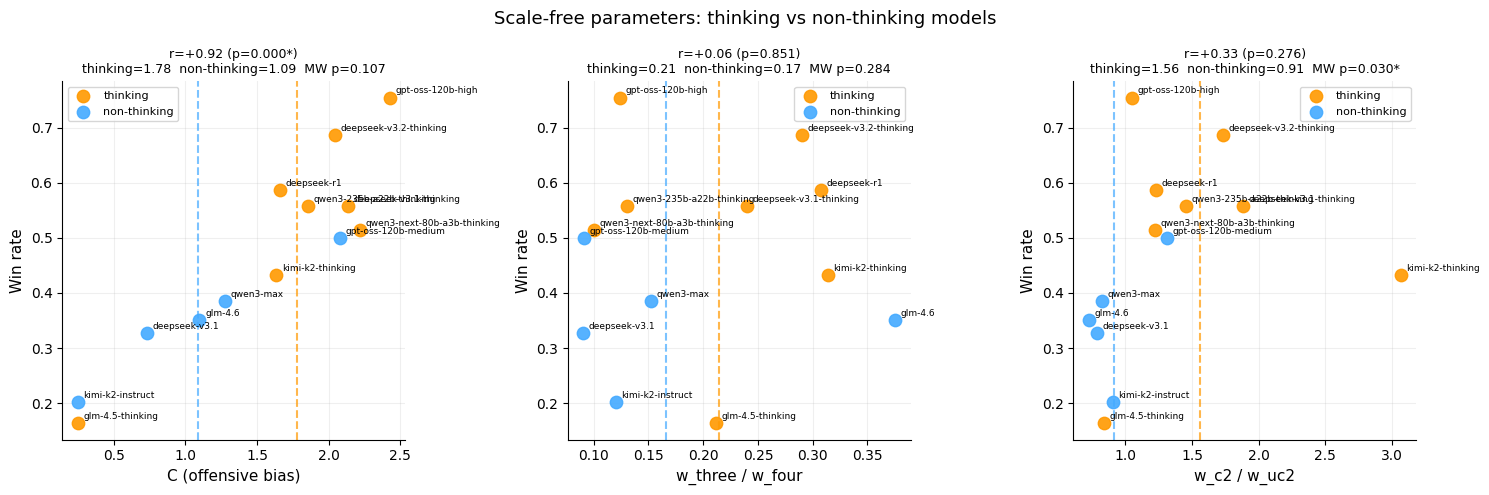


Group means:
              C_ratio  three_four  c2_uc2
group                                    
non-thinking    1.088       0.166   0.912
thinking        1.779       0.215   1.559


In [40]:
from scipy.stats import mannwhitneyu, pearsonr

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

think_color    = '#ff9900'
nonthink_color = '#44aaff'

for ax, col, label in zip(axes, RATIO_COLS, RATIO_LABELS):
    sub = df_ratio.dropna(subset=[col, 'win_rate'])
    thinking    = sub[sub['is_thinking']]
    nonthinking = sub[~sub['is_thinking']]

    # Scatter: win rate vs ratio, colored by group
    ax.scatter(thinking[col],    thinking['win_rate'],
               c=think_color,    s=80, label='thinking',     alpha=0.9, zorder=3)
    ax.scatter(nonthinking[col], nonthinking['win_rate'],
               c=nonthink_color, s=80, label='non-thinking', alpha=0.9, zorder=3)

    for _, row in sub.iterrows():
        ax.annotate(row['model'], (row[col], row['win_rate']),
                    xytext=(4, 3), textcoords='offset points', fontsize=6.5)

    # Group means as vertical lines
    ax.axvline(thinking[col].mean(),    color=think_color,    lw=1.5, ls='--', alpha=0.7)
    ax.axvline(nonthinking[col].mean(), color=nonthink_color, lw=1.5, ls='--', alpha=0.7)

    # Stats
    r, p_r = pearsonr(sub[col], sub['win_rate'])
    stat, p_mw = mannwhitneyu(thinking[col].dropna(), nonthinking[col].dropna(),
                              alternative='two-sided')
    sig_r  = '*' if p_r  < 0.05 else ('.' if p_r  < 0.1 else '')
    sig_mw = '*' if p_mw < 0.05 else ('.' if p_mw < 0.1 else '')

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Win rate', fontsize=11)
    ax.set_title(
        f'r={r:+.2f} (p={p_r:.3f}{sig_r})\n'
        f'thinking={thinking[col].mean():.2f}  non-thinking={nonthinking[col].mean():.2f}'
        f'  MW p={p_mw:.3f}{sig_mw}',
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('Scale-free parameters: thinking vs non-thinking models', fontsize=13)
plt.tight_layout()
plt.savefig('figures/ratio_params_thinking_split.pdf', facecolor='#444444')
plt.show()

print('\nGroup means:')
print(df_ratio.groupby('group')[RATIO_COLS].mean().round(3))

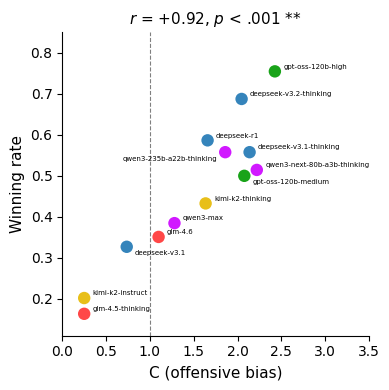

Saved: figures/feature_weights_C_vs_winrate.pdf


In [ ]:

# Standalone: C (offensive bias) vs win rate — per-family colors
from scipy.stats import pearsonr, mannwhitneyu

def model_color_fw(name):
    n = name.lower()
    if 'oss'      in n: return '#009900'
    if 'deepseek' in n: return '#1f77b4'
    if 'qwen'     in n: return '#cc00ff'
    if 'kimi'     in n: return '#e6b800'
    if 'glm'      in n: return '#ff3333'
    if 'llama'    in n: return '#3A3939'
    return '#3A3939'

sub = df_ratio.dropna(subset=['C_ratio', 'win_rate'])
cols = [model_color_fw(m) for m in sub['model']]

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(sub['C_ratio'], sub['win_rate'], c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)


manual_offsets = {
    'qwen3-235b-a22b-thinking': (-74, -6),
    # # 'qwen3-next-80b-a3b-thinking': (6, -6),
    'deepseek-v3.1': (6, -6),
    'gpt-oss-120b-medium': (6, -6),
}

for _, row in sub.iterrows():
    offset = manual_offsets.get(row['model'], (6, 2))
    ax.annotate(row['model'], (row['C_ratio'], row['win_rate']),
                xytext=offset, textcoords='offset points', fontsize=5)

ax.axvline(1, color='gray', lw=0.8, ls='--')


ax.set_xlim(0, 3.5)
ax.set_ylim(0.11, 0.85)

r, p = pearsonr(sub['C_ratio'], sub['win_rate'])
sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ''))

ax.set_title(rf'$r$ = {r:+.2f}, $p$ < .001 {sig}', fontsize=11)
ax.set_xlabel('C (offensive bias)', fontsize=11)
ax.set_ylabel('Winning rate', fontsize=11)
plt.tight_layout()
plt.savefig('figures/feature_weights_C_vs_winrate.pdf', facecolor='white')
plt.show()
print('Saved: figures/feature_weights_C_vs_winrate.pdf')


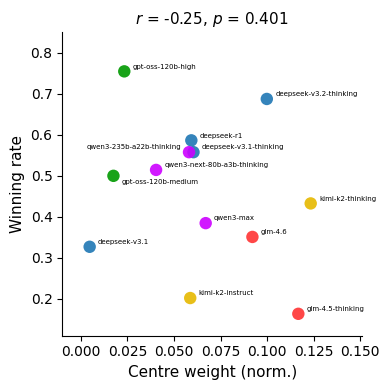

In [51]:
# Centre weight (norm.) vs win rate
from scipy.stats import pearsonr

if 'win_rate' not in df_rel.columns:
    df_rel['win_rate'] = df_plot['win_rate']

sub = df_rel.dropna(subset=['w_centre_norm', 'win_rate'])
cols = [model_color_fw(m) for m in sub['model']]

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(sub['w_centre_norm'], sub['win_rate'], c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)


manual_offsets = {
    'qwen3-235b-a22b-thinking': (-74, 2),
    # # 'qwen3-next-80b-a3b-thinking': (6, -6),
    # 'deepseek-v3.1': (6, -6),
    'gpt-oss-120b-medium': (6, -6),
}


for _, row in sub.iterrows():
    offset = manual_offsets.get(row['model'], (6, 2))
    ax.annotate(row['model'], (row['w_centre_norm'], row['win_rate']),
                xytext=offset, textcoords='offset points', fontsize=5)

r, p = pearsonr(sub['w_centre_norm'], sub['win_rate'])
sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ''))

ax.set_title(rf'$r$ = {r:+.2f}, $p$ = {p:.3f} {sig}', fontsize=11)
ax.set_xlabel('Centre weight (norm.)', fontsize=11)
ax.set_ylabel('Winning rate', fontsize=11)
ax.set_xlim(-0.01, 0.151)
ax.set_ylim(0.11, 0.85)
plt.tight_layout()
plt.savefig('figures/feature_weights_w_centre_norm_vs_winrate.pdf', facecolor='white')
plt.show()

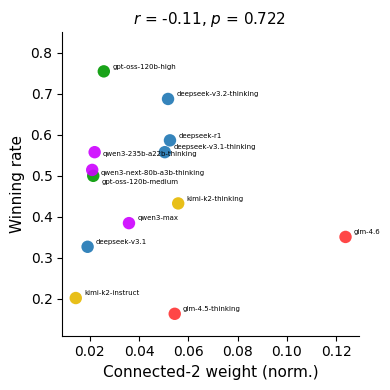

In [50]:
# Connected-2 weight (norm.) vs win rate
sub = df_rel.dropna(subset=['w_c2_norm', 'win_rate'])
cols = [model_color_fw(m) for m in sub['model']]

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(sub['w_c2_norm'], sub['win_rate'], c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)

manual_offsets = {
    'qwen3-235b-a22b-thinking': (6, -3),
    'qwen3-next-80b-a3b-thinking': (6, -4),
    # 'deepseek-v3.1': (6, -6),
    'gpt-oss-120b-medium': (6, -6),
}


for _, row in sub.iterrows():
    offset = manual_offsets.get(row['model'], (6, 2))
    ax.annotate(row['model'], (row['w_c2_norm'], row['win_rate']),
                xytext=offset, textcoords='offset points', fontsize=5)

r, p = pearsonr(sub['w_c2_norm'], sub['win_rate'])
sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ''))

ax.set_title(rf'$r$ = {r:+.2f}, $p$ = {p:.3f} {sig}', fontsize=11)
ax.set_xlabel('Connected-2 weight (norm.)', fontsize=11)
ax.set_ylabel('Winning rate', fontsize=11)
ax.set_ylim(0.11, 0.85)
plt.tight_layout()
plt.savefig('figures/feature_weights_w_c2_norm_vs_winrate.pdf', facecolor='white')
plt.show()

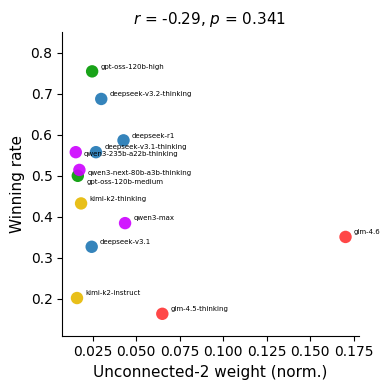

In [52]:
# Unconnected-2 weight (norm.) vs win rate
sub = df_rel.dropna(subset=['w_uc2_norm', 'win_rate'])
cols = [model_color_fw(m) for m in sub['model']]

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(sub['w_uc2_norm'], sub['win_rate'], c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)

manual_offsets = {
    'qwen3-235b-a22b-thinking': (6, -3),
    'qwen3-next-80b-a3b-thinking': (6, -4),
    # 'deepseek-v3.1': (6, -6),
    'gpt-oss-120b-medium': (6, -6),
}
    

for _, row in sub.iterrows():
    offset = manual_offsets.get(row['model'], (6, 2))
    ax.annotate(row['model'], (row['w_uc2_norm'], row['win_rate']),
                xytext=offset, textcoords='offset points', fontsize=5)

r, p = pearsonr(sub['w_uc2_norm'], sub['win_rate'])
sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ''))

ax.set_title(rf'$r$ = {r:+.2f}, $p$ = {p:.3f} {sig}', fontsize=11)
ax.set_xlabel('Unconnected-2 weight (norm.)', fontsize=11)
ax.set_ylabel('Winning rate', fontsize=11)
ax.set_ylim(0.11, 0.85)
plt.tight_layout()
plt.savefig('figures/feature_weights_w_uc2_norm_vs_winrate.pdf', facecolor='white')
plt.show()

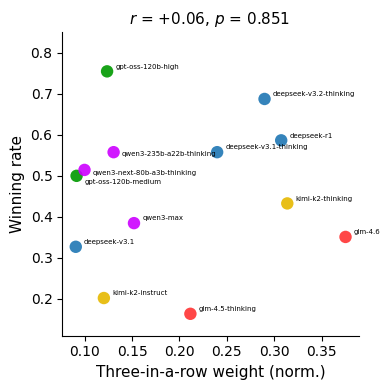

In [53]:
# Three-in-a-row weight (norm.) vs win rate
sub = df_rel.dropna(subset=['w_three_norm', 'win_rate'])
cols = [model_color_fw(m) for m in sub['model']]

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(sub['w_three_norm'], sub['win_rate'], c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)

manual_offsets = {
    'qwen3-235b-a22b-thinking': (6, -3),
    'qwen3-next-80b-a3b-thinking': (6, -4),
    # 'deepseek-v3.1': (6, -6),
    'gpt-oss-120b-medium': (6, -6),
}

for _, row in sub.iterrows():
    offset = manual_offsets.get(row['model'], (6, 2))
    ax.annotate(row['model'], (row['w_three_norm'], row['win_rate']),
                xytext=offset, textcoords='offset points', fontsize=5)

r, p = pearsonr(sub['w_three_norm'], sub['win_rate'])
sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ''))

ax.set_title(rf'$r$ = {r:+.2f}, $p$ = {p:.3f} {sig}', fontsize=11)
ax.set_xlabel('Three-in-a-row weight (norm.)', fontsize=11)
ax.set_ylabel('Winning rate', fontsize=11)
ax.set_ylim(0.11, 0.85)
plt.tight_layout()
plt.savefig('figures/feature_weights_w_three_norm_vs_winrate.pdf', facecolor='white')
plt.show()